<a href="https://colab.research.google.com/github/aajyaparamesh-max/Internship/blob/main/Project_2_Customer_Segmentation_and_Product_Recommendations_in_E_Commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Project Title**

Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce

#**Problem Type**

Unsupervised Machine Learning – Clustering

Collaborative Filtering – Recommendation System


#**Contribution** - Individual

#**Project Summary**

The rapid growth of the e-commerce industry has generated vast amounts of transactional data, creating opportunities for businesses to better understand customer behavior and enhance customer experiences. This project focuses on analyzing online retail transaction data to identify meaningful customer segments and develop a personalized product recommendation system.

The project begins with comprehensive data preprocessing, including handling missing values, removing duplicate records, excluding cancelled transactions, and filtering invalid quantity and price entries. Exploratory Data Analysis (EDA) is then performed to uncover key business insights such as top-selling products, country-wise transaction distribution, customer spending patterns, and sales trends over time.

To segment customers, Recency-Frequency-Monetary (RFM) analysis is conducted. Recency measures how recently a customer made a purchase, Frequency captures how often purchases occur, and Monetary represents the total amount spent. The RFM features are standardized and used as inputs for multiple clustering algorithms, including K-Means, Hierarchical Clustering, DBSCAN, and Gaussian Mixture Models (GMM). These models are evaluated using clustering metrics such as Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score to identify the most effective segmentation approach. Customers are then categorized into business-friendly segments such as High-Value, Regular, Occasional, and At-Risk customers.

In addition to customer segmentation, the project implements a product recommendation engine using Collaborative Filtering techniques. Multiple recommendation approaches, including Item-Based Collaborative Filtering, User-Based Collaborative Filtering, and Singular Value Decomposition (SVD), are developed and compared. Product similarities are computed using cosine similarity to generate personalized product recommendations.

Finally, the best-performing clustering and recommendation models are integrated into an interactive Streamlit web application. The application enables users to predict customer segments using RFM values and receive product recommendations based on product names. This solution helps businesses improve customer retention, optimize marketing strategies, and increase sales through data-driven decision-making and personalized customer engagement.

#**GitHub Link -**

#**Problem Statement**
The global e-commerce industry generates vast amounts of transaction data daily, offering valuable insights into customer purchasing behaviors. Analyzing this data is essential for identifying meaningful customer segments and recommending relevant products to enhance customer experience and drive business growth. This project aims to examine transaction data from an online retail business to uncover patterns in customer purchase behavior, segment customers based on Recency, Frequency, and Monetary (RFM) analysis, and develop a product recommendation system using collaborative filtering techniques.


#**Dataset Understanding**

In [2]:
#Import Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date handling
from datetime import datetime

# Scaling
from sklearn.preprocessing import StandardScaler

# Clustering Models
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# Evaluation Metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Recommendation System
from sklearn.metrics.pairwise import cosine_similarity

# PCA for visualization
from sklearn.decomposition import PCA

# Save Models
import pickle

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [6]:
# Load Data

try:
    df = pd.read_csv('/content/CustomerSegmentation/online_retail.csv')

    print("Dataset Loaded Successfully")
    print(f"Dataset Shape : {df.shape}")

except FileNotFoundError:
    print("Error: Dataset file not found.")

except Exception as e:
    print("Error:", e)

Dataset Loaded Successfully
Dataset Shape : (541909, 8)


In [7]:
# to know the dataset dimension and datatypes in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
# to know the statistical summary of the numerical features
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
# Check for Null values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [10]:
# Check for duplicate Records
df.duplicated().sum()

np.int64(5268)

#**Data Preprocessing**

In [11]:
#Datatype Conversion

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert categorical columns
categorical_cols = ['InvoiceNo', 'StockCode', 'Description', 'Country']
df[categorical_cols] = df[categorical_cols].astype('category')

# CustomerID should be treated as categorical, not numeric
df['CustomerID'] = df['CustomerID'].astype('Int64')

# Quantity should remain integer
df['Quantity'] = df['Quantity'].astype('int32')

# UnitPrice should remain float
df['UnitPrice'] = df['UnitPrice'].astype('float32')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  category      
 1   StockCode    541909 non-null  category      
 2   Description  540455 non-null  category      
 3   Quantity     541909 non-null  int32         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float32       
 6   CustomerID   406829 non-null  Int64         
 7   Country      541909 non-null  category      
dtypes: Int64(1), category(4), datetime64[ns](1), float32(1), int32(1)
memory usage: 18.1 MB


In [13]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [14]:
# Dataset Dimension before processing

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 541909
Number of Columns : 8


In [15]:
#Remove Missing CustomerID
df = df.dropna(subset=['CustomerID'])

In [16]:
#Remove Cancelled Orders

#Invoices beginning with C indicate cancellation.

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [17]:
#Remove Negative Quantity
df = df[df['Quantity'] > 0]

In [18]:
#Remove Negative Prices
df = df[df['UnitPrice'] > 0]

In [19]:
#Create Total Amount
df['SalesAmount'] = df['Quantity'] * df['UnitPrice']

In [20]:
# Dataset Dimension after processing

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")
# New feature 'Total Amount' is added

Number of Rows    : 397884
Number of Columns : 9


In [21]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
SalesAmount,0


#**Exploratory Data Analysis**

**Univariate Analysis**

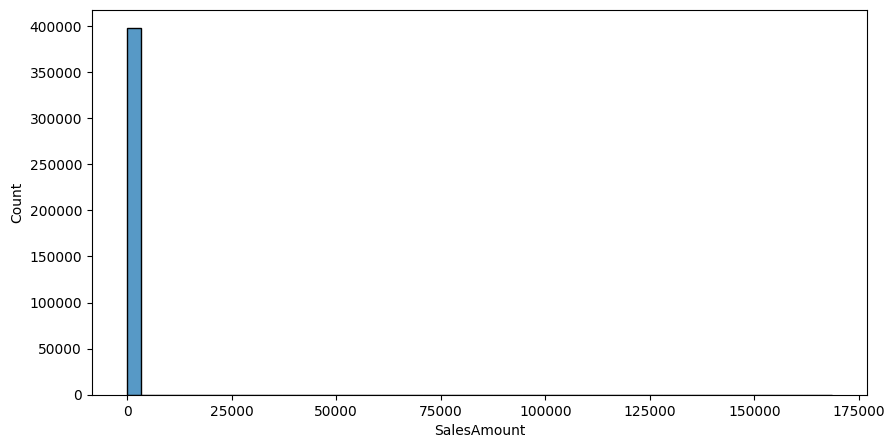

In [22]:
# Sales Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['SalesAmount'],bins=50)

plt.show()

# Inference
# Most transactions are low-value.
# Few high-value transactions contribute significantly to revenue.

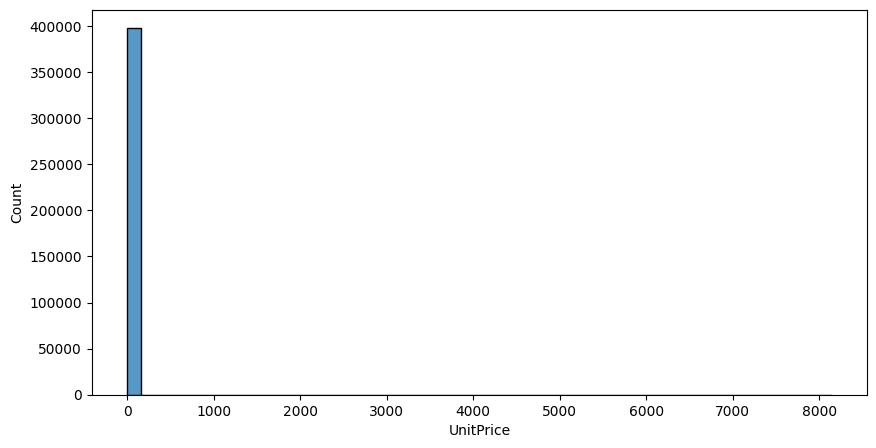

In [23]:
# Unit Price Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['UnitPrice'], bins=50)

plt.show()

# Inference
# Majority of products belong to lower price ranges.
# A few premium products create a long-tail distribution.



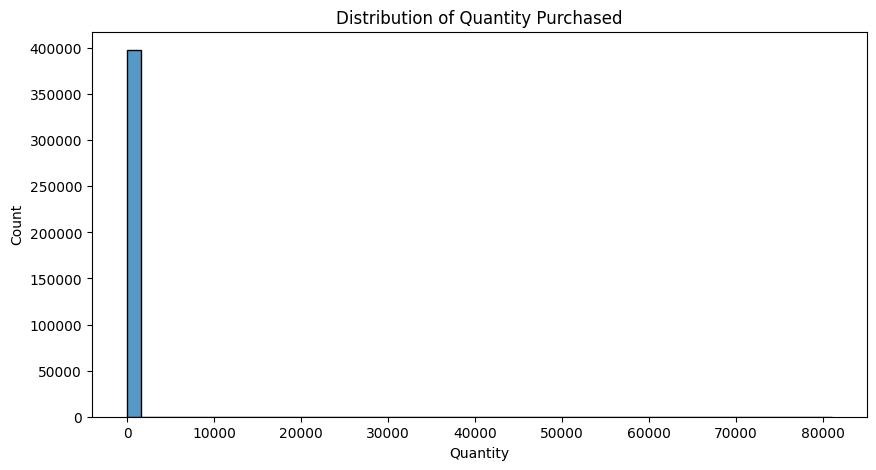

In [24]:
# Quantity Distribution

plt.figure(figsize=(10,5))

sns.histplot(df['Quantity'], bins=50)

plt.title("Distribution of Quantity Purchased")

plt.show()

#Inference
# Most purchases involve small quantities.
# Large quantity purchases may represent wholesale customers.

**Bivariate Analysis**

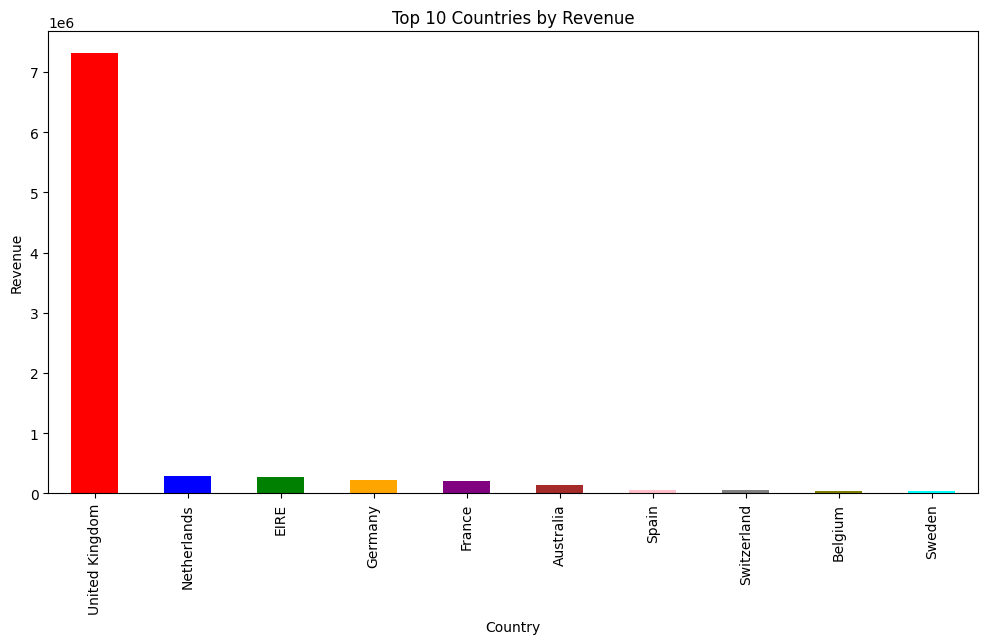

In [25]:
#Top 10 Countries by Revenue

# plt.figure(figsize=(10,5))

# df['Country'].value_counts().head(10).plot(
#     kind='bar'
# )

# plt.title("Top Countries")
# plt.show()

country_sales = (df.groupby('Country')['SalesAmount'].sum().sort_values(ascending=False).head(10))

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

country_sales.plot(kind='bar',color=colors,figsize=(12,6))
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

# Inference
# Revenue concentration may differ from transaction volume.
# High-value markets can be targeted with marketing campaigns.

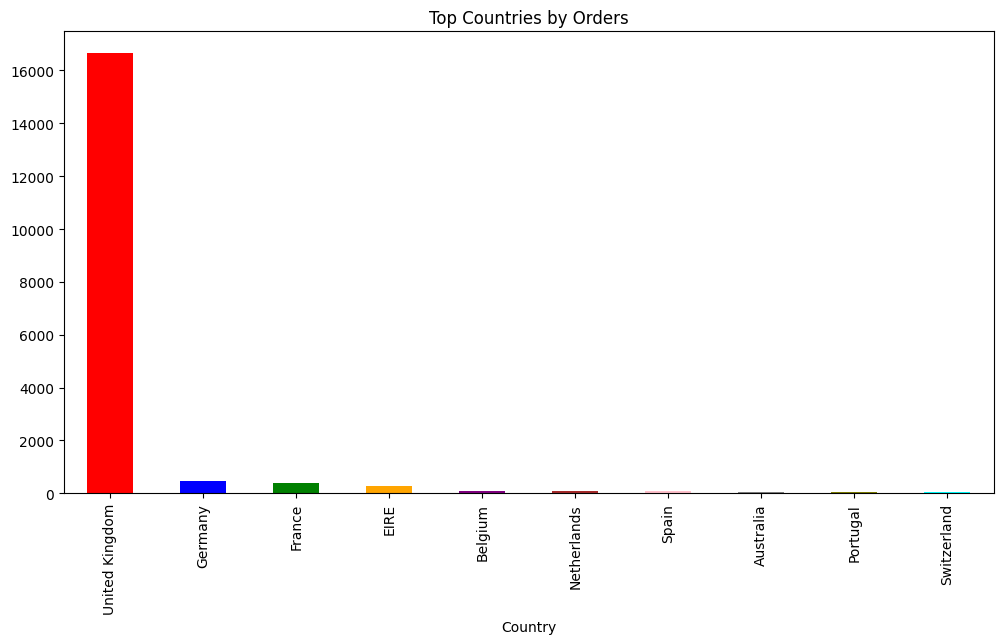

In [26]:
#Top 10 Countries by Number of Orders

country_orders = (df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10))

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

country_orders.plot(kind='bar',color=colors,figsize=(12,6))
plt.title("Top Countries by Orders")
plt.show()

#Inference
# United Kingdom usually dominates transaction volume.
# Business is heavily dependent on UK customers.
# Opportunity exists to increase sales in other countries.

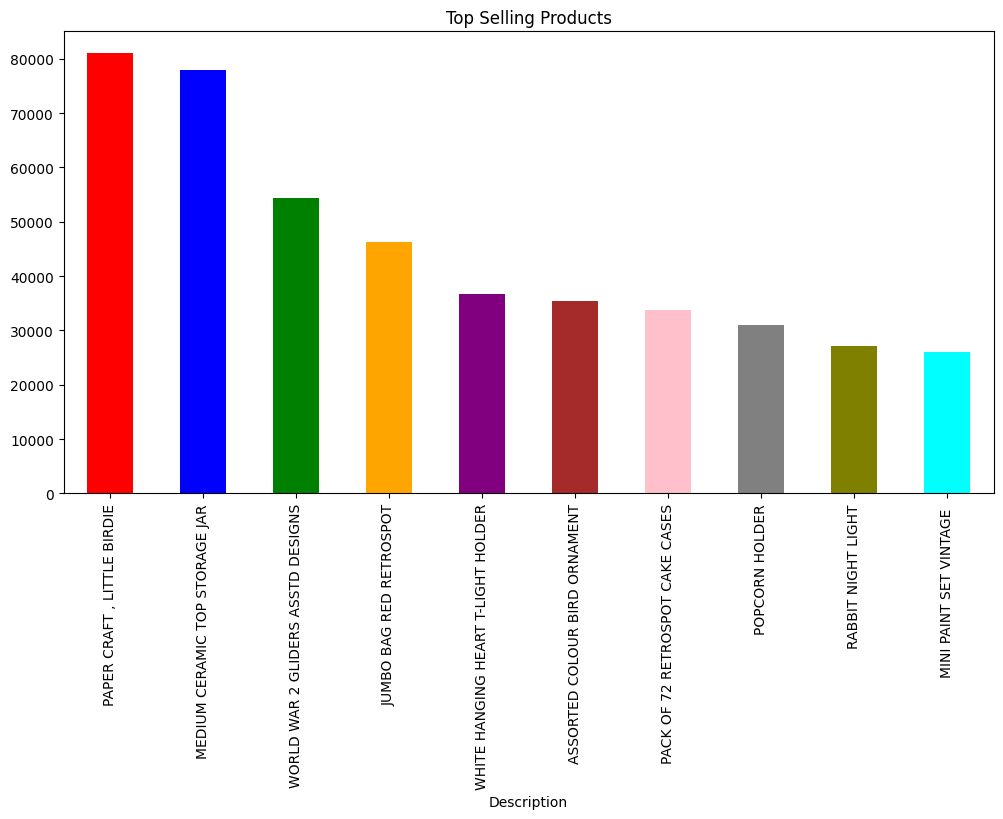

In [27]:
# Top 10 Selling Products

top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

top_products.plot(kind='bar',color=colors,figsize=(12,6))
plt.title("Top Selling Products")
plt.show()

# Inference
# Best-selling products represent customer preferences.
# These products should be prioritized in inventory planning.
# Ideal candidates for recommendation systems.

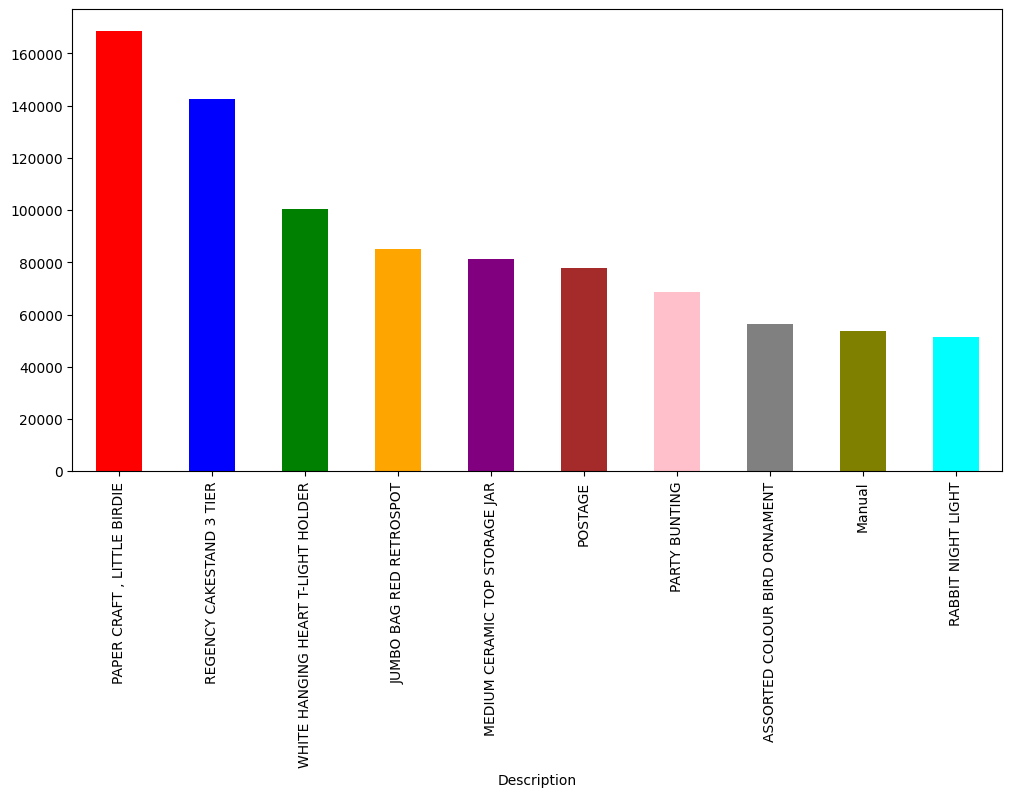

In [28]:
#Top 10 Revenue Generating Products
top_revenue_products = ( df.groupby('Description')['SalesAmount'].sum().sort_values(ascending=False).head(10))

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

top_revenue_products.plot(kind='bar',color=colors,figsize=(12,6))

plt.show()

# Inference:
# Best-selling products are not always the highest revenue products.

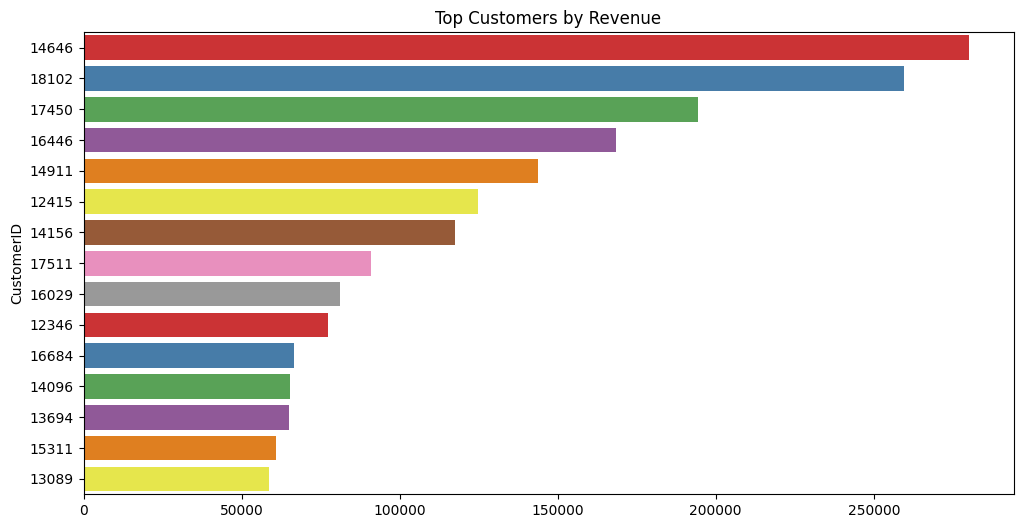

In [29]:
# Top Customers by Spending
top_customers = (df.groupby('CustomerID')['SalesAmount'].sum().sort_values(ascending=False).head(15))

plt.figure(figsize=(12,6))

sns.barplot(x=top_customers.values,y=top_customers.index.astype(str),palette='Set1')

plt.title("Top Customers by Revenue")

plt.show()

# Inference
# Small percentage of customers contribute large revenue.
# Loyalty programs can focus on these customers.

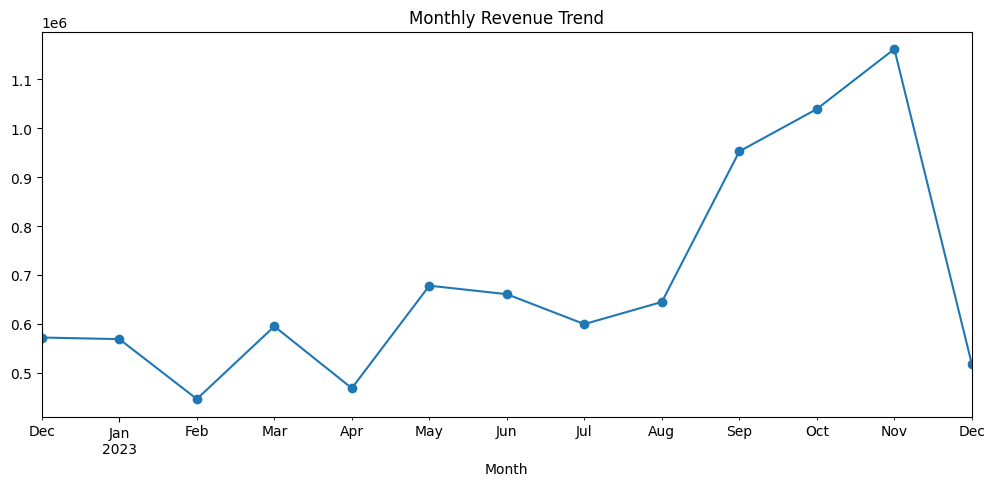

In [30]:
# Create Month column
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = ( df.groupby('Month')['SalesAmount'].sum())

# Monthly Revenue Trend
monthly_sales.plot(figsize=(12,5),marker='o')
plt.title("Monthly Revenue Trend")
plt.show()

# Inference
# Peak sales months indicate seasonal demand.
# Helps demand forecasting and inventory planning.

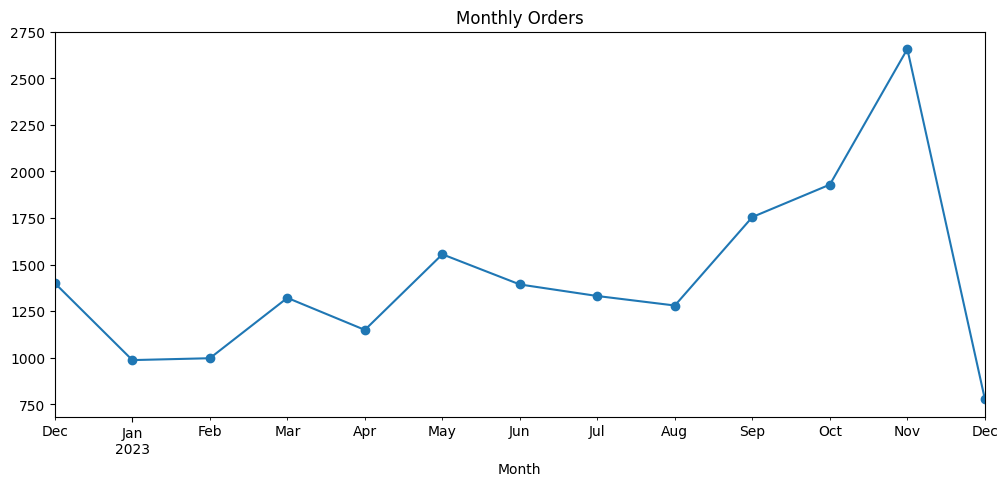

In [31]:
# Monthly Order Trend
monthly_orders = (df.groupby('Month')['InvoiceNo'].nunique())

monthly_orders.plot(figsize=(12,5),marker='o')
plt.title("Monthly Orders")
plt.show()

# Inference
# Shows customer activity over time.
# Useful for identifying growth or decline periods.

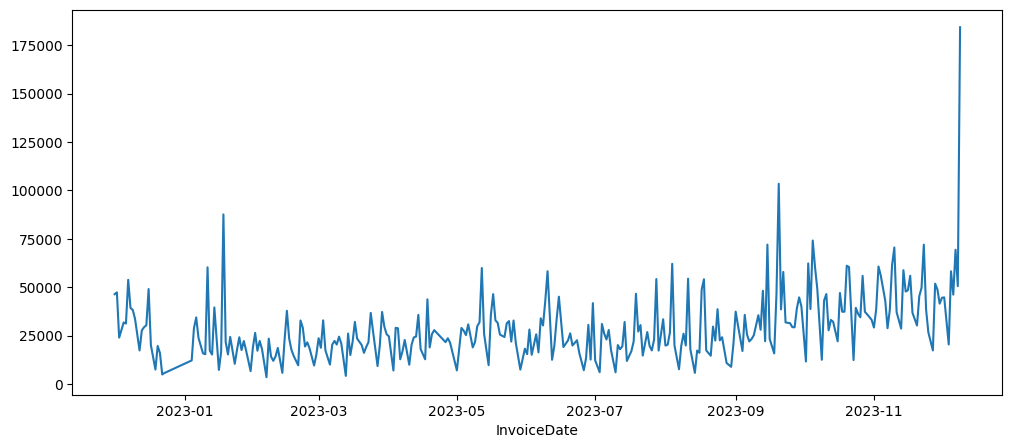

In [32]:
# Daily Sales Trend
daily_sales = (df.groupby(df['InvoiceDate'].dt.date)['SalesAmount'].sum())

daily_sales.plot(figsize=(12,5))
plt.show()

#Inference:
# Significant Sales Spikes
# Strong Year-End Performance
# High variablity in daily sales

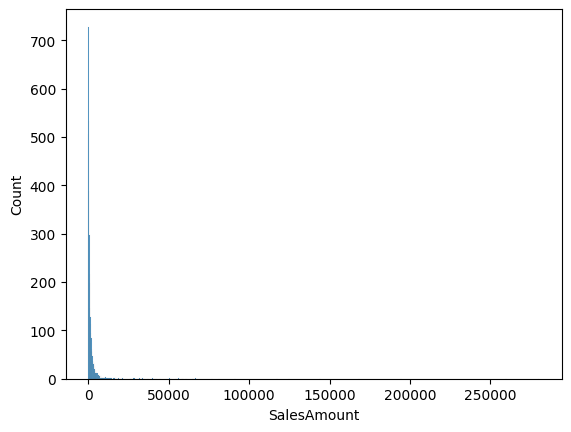

In [33]:
# Customer Revenue Distribution

customer_revenue = (
    df.groupby('CustomerID')
    ['SalesAmount']
    .sum()
)

sns.histplot(customer_revenue)
plt.show()

# Inference
# The customer revenue distribution is highly right-skewed, indicating that most customers generate relatively low revenue while a small number of customers contribute exceptionally high revenue.
# This suggests a Pareto (80/20) effect, where a small segment of high-value customers drives a significant portion of overall sales revenue.

***Multivariate Analysis***

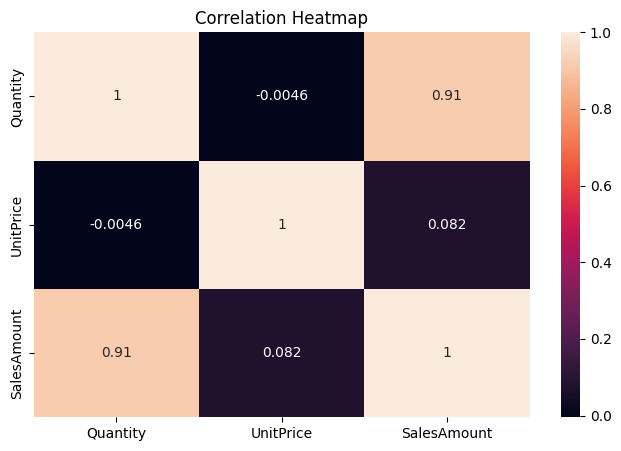

In [34]:
# Correlation Heatmap
plt.figure(figsize=(8,5))

sns.heatmap(df[['Quantity', 'UnitPrice', 'SalesAmount']].corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

# Inference
# SalesAmount usually has strong positive relation with Quantity.
# UnitPrice contributes significantly to revenue.

Quantity ↔ SalesAmount	0.91	=> Very strong positive correlation

UnitPrice ↔ SalesAmount	0.082	=> Very weak positive correlation

Quantity ↔ UnitPrice	-0.0046	=> No meaningful correlation

The correlation analysis reveals that Total Revenue is strongly influenced by the number of items sold (91% correlation), while product pricing has minimal impact on overall sales value. Therefore, strategies aimed at increasing purchase volume are likely to yield greater revenue growth than price adjustments alone.

#**RFM Analysis**

**Feature Engineering (RFM)**

In [35]:
# Create RFM Table

# Snapshot date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM Calculation
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'SalesAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.reset_index(inplace=True)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.597169
1,12347,2,7,4309.999988
2,12348,75,4,1797.239997
3,12349,19,1,1757.549994
4,12350,310,1,334.399997


In [36]:
rfm.isnull().sum()

,0
CustomerID,0
Recency,0
Frequency,0
Monetary,0


In [37]:
df[['CustomerID','InvoiceDate','InvoiceNo','SalesAmount']].isnull().sum()

,0
CustomerID,0
InvoiceDate,0
InvoiceNo,0
SalesAmount,0


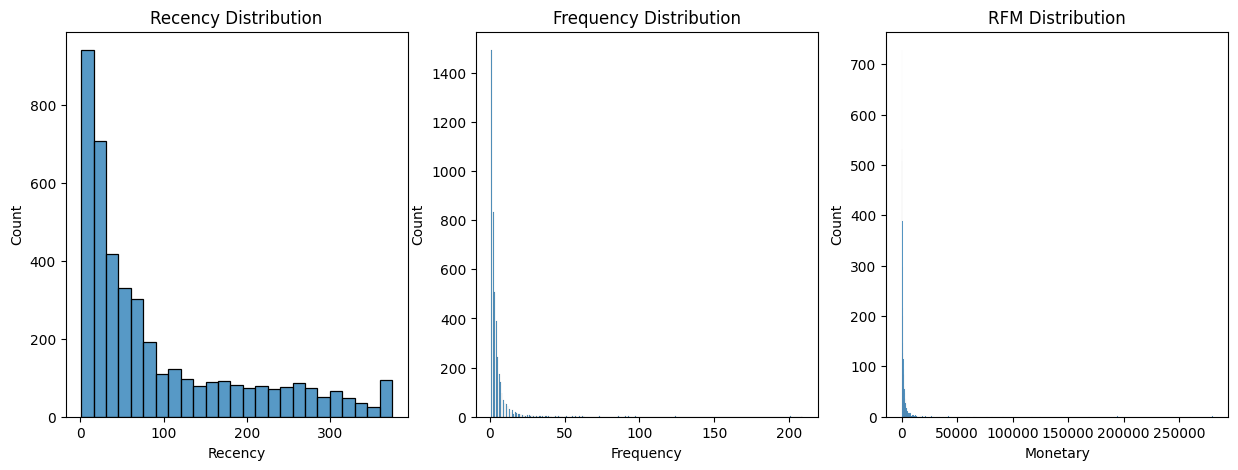

In [38]:
# RFM Distribution

fig, axes = plt.subplots( 1, 3, figsize=(15,5))

sns.histplot(rfm['Recency'], ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm['Frequency'], ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm['Monetary'], ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.title("RFM Distribution")
plt.show()

#*Inference*

Most customers purchase infrequently.

Spending distribution is highly skewed.

Some customers are inactive for long periods.




# **Standardize RFM Values**
Standardisation is required as Recency, Frequency and Monetary have different scales. Without scaling, Monetary dominates clustering.

In [41]:
# Scale Features
scaler = StandardScaler()

#rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

#rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)

rfm_scaled.head()

# Inference

# Mean approximately 0
# Standard deviation approximately 1
# All variables contribute equally.

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347


# **Elbow Curve**

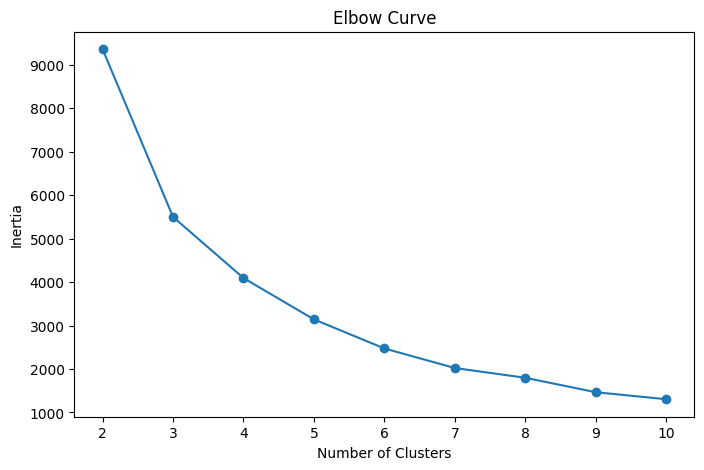

In [42]:
# Elbow Curve - How many customer segments should be created?

inertia = []

for k in range(2,11):
    kMeans_model = KMeans( n_clusters=k, random_state=42)
    kMeans_model.fit(rfm_scaled)
    inertia.append( kMeans_model.inertia_)


plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.title("Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Inference

# Point where curve bends significantly indicates optimal K.
# Usually K = 4 is selected for customer segmentation.

#**Silhouette Analysis**

In [43]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    km = KMeans(n_clusters=k, random_state=42)

    labels = km.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    print( f"K={k} --> Silhouette Score={score:.4f}" )

# Inference
# Higher score indicates better cluster separation.
# Select K with highest silhouette score and reasonable business interpretation.

K=2 --> Silhouette Score=0.5604
K=3 --> Silhouette Score=0.5853
K=4 --> Silhouette Score=0.6162
K=5 --> Silhouette Score=0.6171
K=6 --> Silhouette Score=0.5983
K=7 --> Silhouette Score=0.5172
K=8 --> Silhouette Score=0.4909
K=9 --> Silhouette Score=0.4840
K=10 --> Silhouette Score=0.4250


#**Clustering Models**

#**Model 1: KMeans Clustering**

In [44]:
# K=6 --> Silhouette Score=0.4092
# Considering k as 6 as it has the highest Silhouette Score
kmeans = KMeans(n_clusters=6, random_state=42)

kmeans_labels = kmeans.fit_predict(rfm_scaled)

# **Model 2: Hierarchical Clustering**

In [45]:
hc = AgglomerativeClustering( n_clusters=6)

hc_labels = hc.fit_predict(rfm_scaled)

# **Model 3: DBSCAN**

In [46]:
dbscan = DBSCAN( eps=0.8, min_samples=6)

dbscan_labels = dbscan.fit_predict(rfm_scaled)

# **Model 4: Gaussian Mixture Model**

In [47]:
gmm = GaussianMixture( n_components=6, random_state=42)

gmm_labels = gmm.fit_predict(rfm)

#**Model Comparison**

In [48]:
comparison = pd.DataFrame()

#**Evaluation Function**

In [49]:
def evaluate_model(
    data,
    labels,
    model_name
):

    return pd.DataFrame({

        'Model':[model_name],

        'Silhouette Score':[
            silhouette_score(
                data,
                labels
            )
        ],

        'Davies Bouldin':[
            davies_bouldin_score(
                data,
                labels
            )
        ],

        'Calinski Harabasz':[
            calinski_harabasz_score(
                data,
                labels
            )
        ]
    })

#**Copare Models**

In [50]:
comparison = pd.concat([

    evaluate_model(
        rfm_scaled,
        kmeans_labels,
        'KMeans'
    ),

    evaluate_model(
        rfm_scaled,
        hc_labels,
        'Hierarchical'
    ),

     evaluate_model(
        rfm_scaled,
        dbscan_labels,
        'DBSCAN'
    ),

    evaluate_model(
        rfm_scaled,
        gmm_labels,
        'GMM'
    )

])

comparison

,Model,Silhouette Score,Davies Bouldin,Calinski Harabasz
0,KMeans,0.598272,0.626962,3693.648486
0,Hierarchical,0.451849,0.844726,3126.052068
0,DBSCAN,0.860145,0.875714,1617.258910
0,GMM,0.011028,1.973983,615.233988


#**Best Model Selection**

In [51]:
comparison.sort_values(
    by='Silhouette Score',
    ascending=False
)

# Inference

# Choose:

# Highest Silhouette Score
# Lowest Davies-Bouldin Score
# Highest Calinski-Harabasz Score

#

,Model,Silhouette Score,Davies Bouldin,Calinski Harabasz
0,DBSCAN,0.860145,0.875714,1617.258910
0,KMeans,0.598272,0.626962,3693.648486
0,Hierarchical,0.451849,0.844726,3126.052068
0,GMM,0.011028,1.973983,615.233988


In [72]:
pd.Series(dbscan_labels).value_counts()

,count
0,4277
-1,61


#**Although DBSCAN achieved the highest Silhouette Score (0.860145), it produced only one dominant cluster containing 99% of customers and classified the remaining customers as noise(Outliers).**

In [52]:
pd.Series(kmeans_labels).value_counts()

,count
0,2930
1,1059
3,322
5,21
4,4
2,2


#**K-Means clustering is selected as the final model as it generated well-distributed, interpretable customer segments and supports prediction for new customers in the Streamlit application.**

#**3D Cluster Visualization**

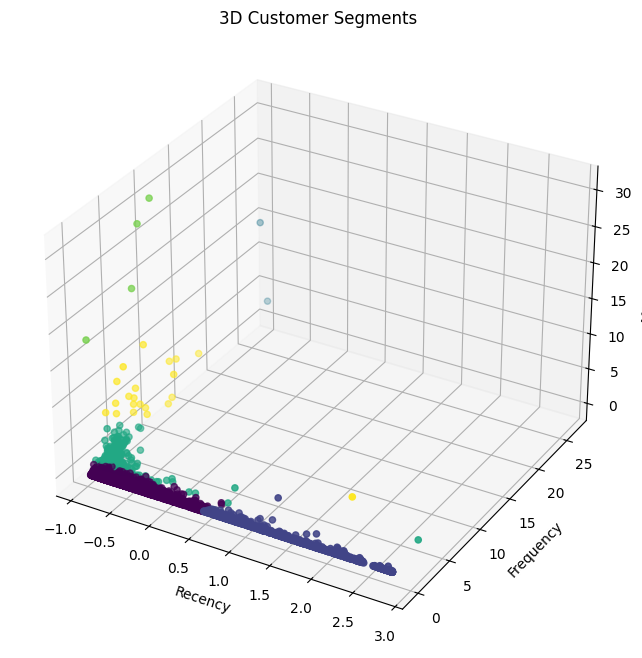

In [53]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(
    figsize=(10,8)
)

ax = fig.add_subplot(
    111,
    projection='3d'
)

scatter = ax.scatter(

    rfm_scaled['Recency'],

    rfm_scaled['Frequency'],

    rfm_scaled['Monetary'],

    c=kmeans_labels
)

ax.set_xlabel('Recency')

ax.set_ylabel('Frequency')

ax.set_zlabel('Monetary')

plt.title(
    '3D Customer Segments'
)

plt.show()

#**Customer Cluster Profiling**

In [55]:

rfm['Cluster'] = kmeans_labels

cluster_profile = (

    rfm.groupby('Cluster')

    [['Recency',
      'Frequency',
      'Monetary']]

    .mean()
)

cluster_profile


,Recency,Frequency,Monetary
Cluster,,,
0,45.141638,3.311604,1212.263482
1,248.938621,1.550519,518.608280
2,1.000000,205.000000,88772.394565
3,15.680124,16.953416,7762.648926
4,3.000000,45.250000,225721.650669
5,22.333333,54.142857,58584.063391


#**Assigning Segment Names**

In [56]:
segment_map = {

    0:'High-Value',

    1:'Regular',

    2:'Occasional',

    3:'At-Risk'
}

rfm['Segment'] = (
    rfm['Cluster']
    .map(segment_map)
)

# Inference - Segment	Interpretation

# High-Value == Recent, frequent, high spenders
# Regular	== Consistent buyers
# Occasional == Low frequency customers
# At-Risk	== Haven't purchased recently

#**PCA Cluster Visualization**

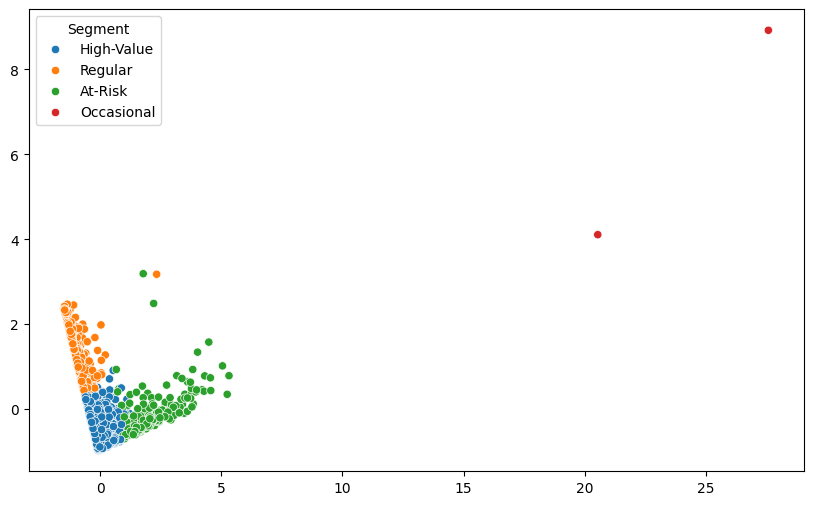

In [57]:
pca = PCA(
    n_components=2
)

pca_data = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(10,6))

sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=rfm['Segment'])

plt.show()

#**Save Models**

In [58]:
# Save Models
pickle.dump(scaler, open('/content/CustomerSegmentation/scaler.pkl','wb'))

pickle.dump(kmeans, open('/content/CustomerSegmentation/kmeans.pkl','wb'))
pickle.dump(pca, open('/content/CustomerSegmentation/pca.pkl','wb'))


# **Recommendation System**

#**Item-Based Collaborative Filtering**
#**Customer-Product Matrix**

In [59]:
customer_product = pd.pivot_table(df, index='Description', columns='CustomerID', values='Quantity', fill_value=0)

customer_product.head()

CustomerID,12346,12347,12348,12349,12350,12352,12353,12354,12355,12356,...,18273,18274,18276,18277,18278,18280,18281,18282,18283,18287
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50'S CHRISTMAS GIFT BAG LARGE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DOLLY GIRL BEAKER,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
I LOVE LONDON MINI BACKPACK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
I LOVE LONDON MINI RUCKSACK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#**Cosine Similarity**

In [60]:
similarity = cosine_similarity(customer_product)

similarity_df = pd.DataFrame(similarity, index=customer_product.index, columns=customer_product.index)

#**Product Similiarity Heatmap**

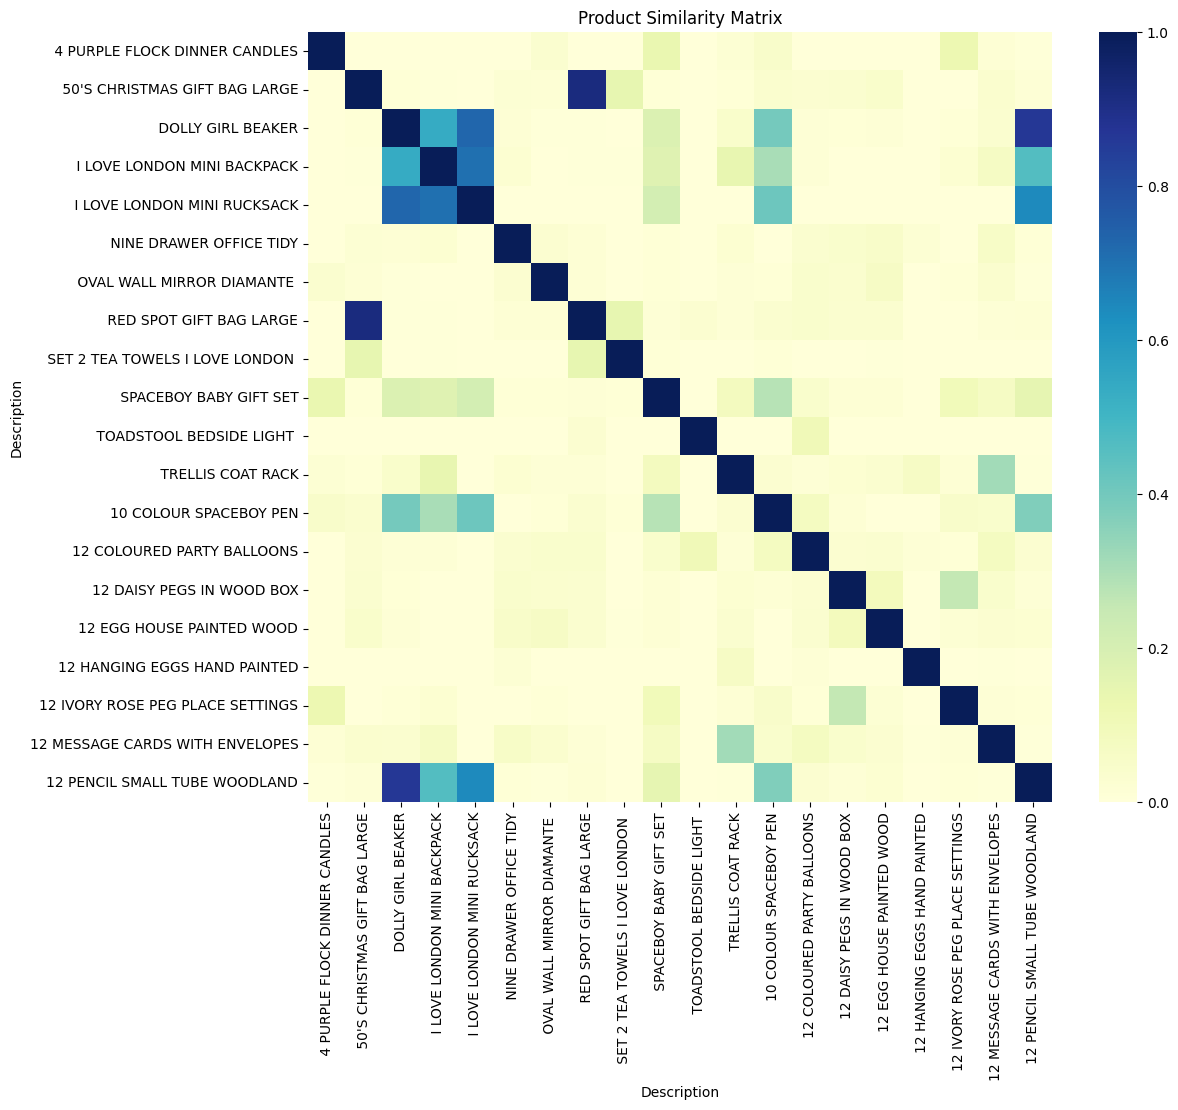

In [61]:
plt.figure(figsize=(12,10))

sns.heatmap(similarity_df.iloc[:20,:20], cmap='YlGnBu')

plt.title('Product Similarity Matrix')

plt.show()

# Inference

# Darker colors indicate stronger similarity.
# Similar products are purchased by similar customers.

#**Recommendation Function**

In [62]:
def recommend_products(product_name, top_n=5):

    if product_name not in similarity_df.index:

        return "Product Not Found"

    recommendations = (similarity_df[product_name].sort_values(ascending=False).iloc[1:top_n+1].index.tolist())

    return recommendations

#**Example**

In [63]:
recommend_products('WHITE HANGING HEART T-LIGHT HOLDER')

['GIN + TONIC DIET METAL SIGN',
 'TEA TIME TEA TOWELS ',
 'FAIRY CAKE FLANNEL ASSORTED COLOUR',
 'DOORMAT FAIRY CAKE',
 'RED HANGING HEART T-LIGHT HOLDER']

#**Save Recommendation Model**

In [64]:
pickle.dump(similarity_df, open('/content/CustomerSegmentation/product_similarity.pkl', 'wb'))